<a href="https://colab.research.google.com/github/vardhamanadarsh/Stock-price-prediction-using-deep-learning-models/blob/main/Windows_layered_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("REPLICATING PAPER: LSTM Stock Price Prediction")
print("Shanghai Composite Index (000001.SS)")
print("="*70)

REPLICATING PAPER: LSTM Stock Price Prediction
Shanghai Composite Index (000001.SS)


In [ ]:
# ==================== 1. LOAD DATA ====================
print("\n[1/5] Loading data...")
ticker = "000001.SS"
data = yf.download(ticker, start="1997-07-03", end="2022-01-25", progress=False)
data = data[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")


[1/5] Loading data...
Data shape: (5951, 5)
Date range: 1997-07-03 00:00:00 to 2022-01-24 00:00:00


In [ ]:
# ==================== 2. TECHNICAL INDICATORS ====================
print("\n[2/5] Adding technical indicators (like paper's macro variables)...")

def add_technical_indicators(df):
    # RSI (like in paper's macro variables)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    macd = exp1 - exp2
    signal = macd.ewm(span=9, adjust=False).mean()
    df['MACD'] = macd - signal

    # Bollinger Bands (volatility indicator)
    rolling_mean = df['Close'].rolling(window=20).mean()
    rolling_std = df['Close'].rolling(window=20).std()
    df['BB'] = (rolling_mean + 2*rolling_std - rolling_mean + 2*rolling_std) / rolling_mean

    # Volume indicator
    df['Volume_MA'] = df['Volume'].rolling(window=20).mean()

    return df.dropna()

data = add_technical_indicators(data)
print(f"Data after indicators: {data.shape}")


[2/5] Adding technical indicators (like paper's macro variables)...
Data after indicators: (5932, 9)


In [ ]:
# ==================== 3. PREPARE DATA (Following Paper's Method) ====================
print("\n[3/5] Preparing sequences...")

# Use only closing price like paper's univariate approach
def create_sequences(data, seq_length):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data.reshape(-1, 1))

    X, y = [], []
    for i in range(seq_length, len(scaled_data)):
        X.append(scaled_data[i-seq_length:i, 0])
        y.append(scaled_data[i, 0])

    return np.array(X), np.array(y), scaler

# Test different window lengths as in paper (15, 30, 45, 60, 75, 90)
window_lengths = [15, 30, 45, 60, 75, 90]

# Use closing price like paper
closing_prices = data['Close'].values

# Prepare data for different window lengths
data_dict = {}
for window in window_lengths:
    X, y, scaler = create_sequences(closing_prices, window)

    # Split 80% train, 20% test (like paper)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Further split for validation (20% of train)
    val_split = int(0.8 * len(X_train))
    X_train_final, X_val = X_train[:val_split], X_train[val_split:]
    y_train_final, y_val = y_train[:val_split], y_train[val_split:]

    data_dict[window] = {
        'X_train': X_train_final,
        'y_train': y_train_final,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
        'scaler': scaler
    }

print(f"Data prepared for {len(window_lengths)} window lengths")


[3/5] Preparing sequences...
Data prepared for 6 window lengths


In [ ]:
# ==================== 4. CREATE LSTM MODELS ====================
print("\n[4/5] Creating LSTM models...")

def create_lstm_model(layers=1, neurons=50, dropout_rate=0.25, input_shape=None):
    """Create LSTM model with specified layers (1, 2, or 3)"""
    model = Sequential()

    # First layer
    if layers == 1:
        model.add(LSTM(neurons, input_shape=input_shape))
    else:
        model.add(LSTM(neurons, return_sequences=True, input_shape=input_shape))
        model.add(Dropout(dropout_rate))

        # Middle layers
        for i in range(1, layers-1):
            model.add(LSTM(neurons, return_sequences=True))
            model.add(Dropout(dropout_rate))

        # Last LSTM layer
        model.add(LSTM(neurons))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1))

    return model


[4/5] Creating LSTM models...


In [ ]:
# ==================== 5. TRAIN MODELS ====================
print("\n[5/5] Training models...")

def train_model(model, X_train, y_train, X_val, y_val, epochs=100, batch_size=64):
    """Train model with early stopping"""
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    return model, history

# Results storage
results = {}

# Window lengths to test (use subset for speed)
test_windows = [30, 45, 60]  # Use these to match paper's best results

for window in test_windows:
    print(f"\n  Evaluating window length: {window}")
    X_train = data_dict[window]['X_train']
    y_train = data_dict[window]['y_train']
    X_val = data_dict[window]['X_val']
    y_val = data_dict[window]['y_val']
    X_test = data_dict[window]['X_test']
    y_test = data_dict[window]['y_test']
    scaler = data_dict[window]['scaler']

    input_shape = (X_train.shape[1], 1)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # Test 1-layer, 2-layer, and 3-layer LSTM (like paper)
    for layers in [1, 2, 3]:
        print(f"    Training {layers}-layer LSTM...", end=" ", flush=True)

        model = create_lstm_model(
            layers=layers,
            neurons=50,
            dropout_rate=0.25,
            input_shape=(input_shape[0], 1)
        )

        model, history = train_model(
            model, X_train, y_train, X_val, y_val,
            epochs=100, batch_size=64
        )

        # Predict
        pred = model.predict(X_test, verbose=0)

        # Inverse transform
        pred = scaler.inverse_transform(pred)
        actual = scaler.inverse_transform(y_test.reshape(-1, 1))

        # Calculate metrics (like paper: MAE, RMSE, MAPE)
        mae = mean_absolute_error(actual, pred)
        rmse = np.sqrt(mean_squared_error(actual, pred))
        mape = np.mean(np.abs((actual - pred) / actual)) * 100

        key = f"Window{window}_Layers{layers}"
        results[key] = {
            'window': window,
            'layers': layers,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'model': model,
            'predictions': pred.flatten(),
            'actual': actual.flatten()
        }

        print(f"Done! MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")


[5/5] Training models...

  Evaluating window length: 30
    Training 1-layer LSTM... Done! MAE: 24.3649, RMSE: 34.4440, MAPE: 0.78%
    Training 2-layer LSTM... Done! MAE: 28.8955, RMSE: 40.3169, MAPE: 0.93%
    Training 3-layer LSTM... Done! MAE: 31.7282, RMSE: 43.8479, MAPE: 1.02%

  Evaluating window length: 45
    Training 1-layer LSTM... Done! MAE: 26.1981, RMSE: 35.5429, MAPE: 0.84%
    Training 2-layer LSTM... Done! MAE: 29.4450, RMSE: 40.7813, MAPE: 0.95%
    Training 3-layer LSTM... Done! MAE: 33.5270, RMSE: 45.7944, MAPE: 1.08%

  Evaluating window length: 60
    Training 1-layer LSTM... Done! MAE: 24.4978, RMSE: 34.6382, MAPE: 0.79%
    Training 2-layer LSTM... Done! MAE: 29.7785, RMSE: 40.8960, MAPE: 0.96%
    Training 3-layer LSTM... Done! MAE: 30.8864, RMSE: 42.2173, MAPE: 0.99%


In [ ]:
# ==================== 6. RESULTS SUMMARY ====================
print("\n" + "="*70)
print("RESULTS SUMMARY (Like Paper Tables 2 & 3)")
print("="*70)

print(f"\n{'Window':<10} {'Layers':<10} {'MAE':<15} {'RMSE':<15} {'MAPE':<15}")
print("-"*65)

for key, res in results.items():
    print(f"{res['window']:<10} {res['layers']:<10} {res['MAE']:<15.4f} {res['RMSE']:<15.4f} {res['MAPE']:<15.2f}%")

# Find best model for each window
print("\n" + "="*70)
print("BEST PERFORMANCE PER WINDOW LENGTH")
print("="*70)

for window in test_windows:
    window_results = {k: v for k, v in results.items() if v['window'] == window}
    best = min(window_results.values(), key=lambda x: x['MAE'])
    print(f"Window {window}: {best['layers']}-layer LSTM - MAE: {best['MAE']:.4f}, MAPE: {best['MAPE']:.2f}%")


RESULTS SUMMARY (Like Paper Tables 2 & 3)

Window     Layers     MAE             RMSE            MAPE           
-----------------------------------------------------------------
30         1          24.3649         34.4440         0.78           %
30         2          28.8955         40.3169         0.93           %
30         3          31.7282         43.8479         1.02           %
45         1          26.1981         35.5429         0.84           %
45         2          29.4450         40.7813         0.95           %
45         3          33.5270         45.7944         1.08           %
60         1          24.4978         34.6382         0.79           %
60         2          29.7785         40.8960         0.96           %
60         3          30.8864         42.2173         0.99           %

BEST PERFORMANCE PER WINDOW LENGTH
Window 30: 1-layer LSTM - MAE: 24.3649, MAPE: 0.78%
Window 45: 1-layer LSTM - MAE: 26.1981, MAPE: 0.84%
Window 60: 1-layer LSTM - MAE: 24.4978, M


Generating plots...


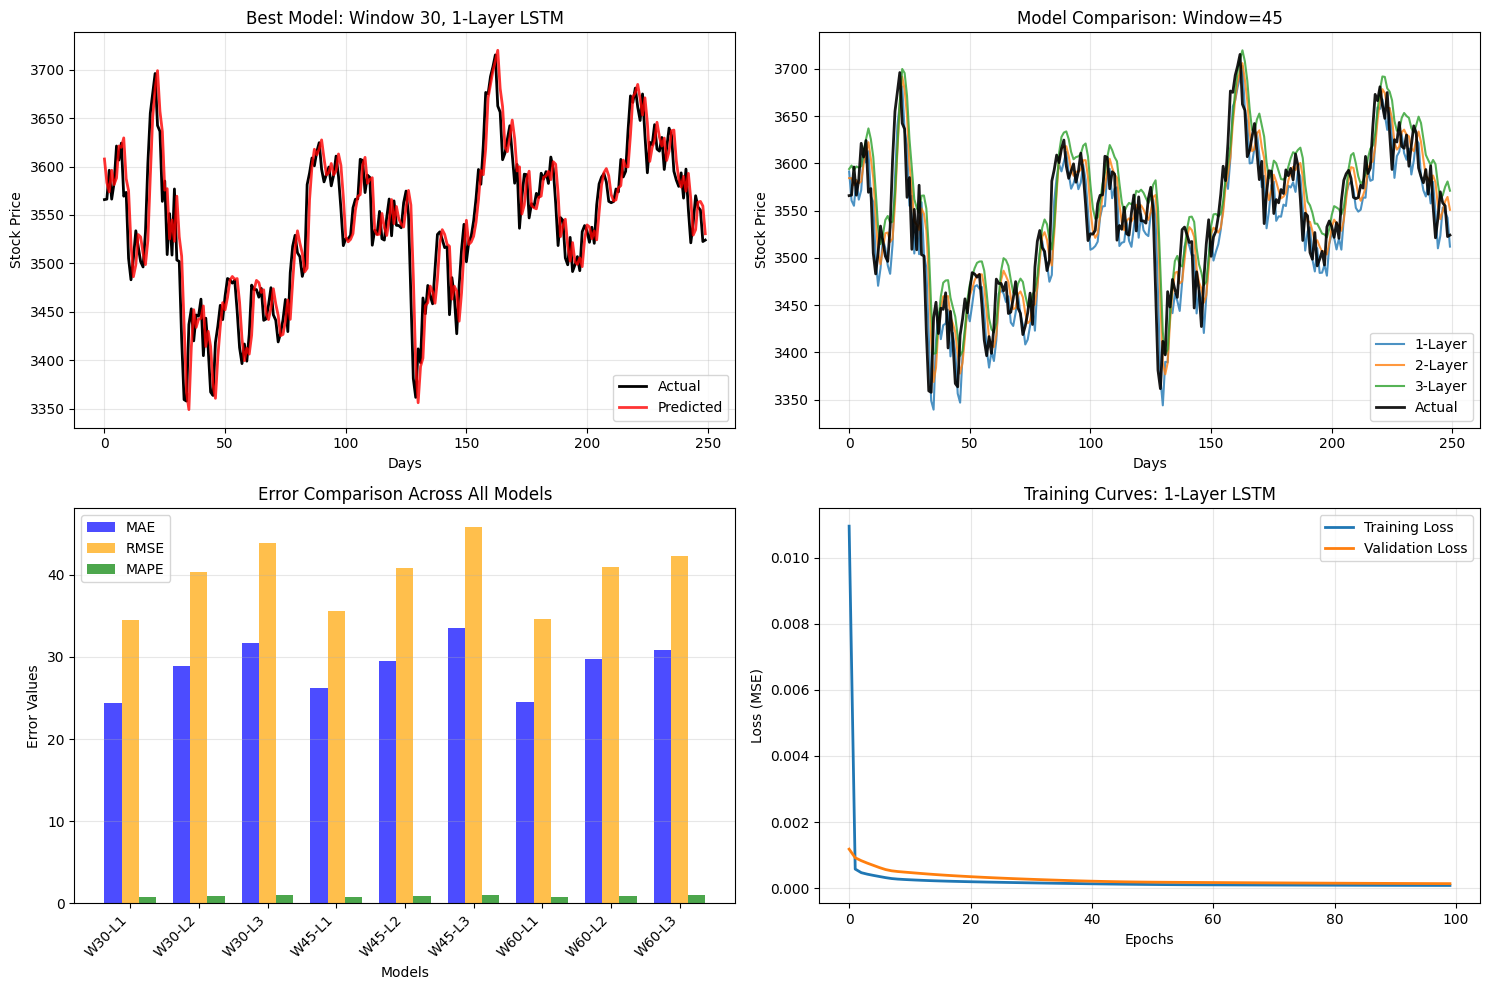

In [ ]:
# ==================== 7. PLOTTING (Like Paper Figures 4, 5, 6) ====================
print("\nGenerating plots...")

# Select best model for plotting
best_model_key = min(results, key=lambda x: results[x]['MAE'])
best_model = results[best_model_key]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Best model predictions vs actual
ax = axes[0, 0]
ax.plot(best_model['actual'][-250:], 'k-', label='Actual', linewidth=2)
ax.plot(best_model['predictions'][-250:], 'r-', label='Predicted', linewidth=2, alpha=0.8)
ax.set_title(f'Best Model: Window {best_model["window"]}, {best_model["layers"]}-Layer LSTM', fontsize=12)
ax.set_xlabel('Days')
ax.set_ylabel('Stock Price')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Comparison of all models for window=45
ax = axes[0, 1]
window_45 = {k: v for k, v in results.items() if v['window'] == 45}
for key, res in window_45.items():
    ax.plot(res['predictions'][-250:], label=f"{res['layers']}-Layer", alpha=0.8)
ax.plot(res['actual'][-250:], 'k-', label='Actual', linewidth=2, alpha=0.9)
ax.set_title('Model Comparison: Window=45', fontsize=12)
ax.set_xlabel('Days')
ax.set_ylabel('Stock Price')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Error comparison across models
ax = axes[1, 0]
x = np.arange(len(results))
width = 0.25
mae_values = [res['MAE'] for res in results.values()]
rmse_values = [res['RMSE'] for res in results.values()]
mape_values = [res['MAPE'] for res in results.values()]

ax.bar(x - width, mae_values, width, label='MAE', color='blue', alpha=0.7)
ax.bar(x, rmse_values, width, label='RMSE', color='orange', alpha=0.7)
ax.bar(x + width, mape_values, width, label='MAPE', color='green', alpha=0.7)

ax.set_xlabel('Models')
ax.set_ylabel('Error Values')
ax.set_title('Error Comparison Across All Models', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"W{res['window']}-L{res['layers']}" for res in results.values()], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Training loss curves for best model
ax = axes[1, 1]
# Retrain best model to get history (simplified)
model = create_lstm_model(
    layers=best_model['layers'],
    neurons=50,
    dropout_rate=0.25,
    input_shape=(data_dict[best_model['window']]['X_train'].shape[1], 1)
)

X_train = data_dict[best_model['window']]['X_train'].reshape(
    data_dict[best_model['window']]['X_train'].shape[0],
    data_dict[best_model['window']]['X_train'].shape[1], 1
)
X_val = data_dict[best_model['window']]['X_val'].reshape(
    data_dict[best_model['window']]['X_val'].shape[0],
    data_dict[best_model['window']]['X_val'].shape[1], 1
)

model, history = train_model(
    model,
    X_train,
    data_dict[best_model['window']]['y_train'],
    X_val,
    data_dict[best_model['window']]['y_val'],
    epochs=100,
    batch_size=64
)

ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_title(f'Training Curves: {best_model["layers"]}-Layer LSTM', fontsize=12)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss (MSE)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_results.png', dpi=200)
plt.show()

In [ ]:
# ==================== 8. SUMMARY TABLE ====================
print("\n" + "="*70)
print("FINAL SUMMARY (Like Paper Format)")
print("="*70)

# Create DataFrame for results
results_df = pd.DataFrame([
    {
        'Window': res['window'],
        'Layers': res['layers'],
        'MAE': res['MAE'],
        'RMSE': res['RMSE'],
        'MAPE': res['MAPE']
    }
    for res in results.values()
])

print("\nPerformance Comparison:")
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("CONCLUSIONS")
print("="*70)

# Find best and worst
best = results_df.loc[results_df['MAE'].idxmin()]
worst = results_df.loc[results_df['MAE'].idxmax()]

print(f"\nBest Model: Window={int(best['Window'])}, Layers={int(best['Layers'])}")
print(f"  MAE: {best['MAE']:.4f}")
print(f"  RMSE: {best['RMSE']:.4f}")
print(f"  MAPE: {best['MAPE']:.2f}%")

print(f"\nWorst Model: Window={int(worst['Window'])}, Layers={int(worst['Layers'])}")
print(f"  MAE: {worst['MAE']:.4f}")
print(f"  RMSE: {worst['RMSE']:.4f}")
print(f"  MAPE: {worst['MAPE']:.2f}%")

print("\n" + "="*70)
print("COMPLETE! Results saved as 'lstm_results.png'")
print("="*70)


FINAL SUMMARY (Like Paper Format)

Performance Comparison:
 Window  Layers       MAE      RMSE     MAPE
     30       1 24.364876 34.444039 0.783206
     30       2 28.895506 40.316856 0.930753
     30       3 31.728156 43.847875 1.021717
     45       1 26.198087 35.542937 0.837913
     45       2 29.445016 40.781322 0.949982
     45       3 33.526950 45.794354 1.078194
     60       1 24.497756 34.638217 0.787524
     60       2 29.778456 40.896023 0.956432
     60       3 30.886437 42.217256 0.992441

CONCLUSIONS

Best Model: Window=30, Layers=1
  MAE: 24.3649
  RMSE: 34.4440
  MAPE: 0.78%

Worst Model: Window=45, Layers=3
  MAE: 33.5270
  RMSE: 45.7944
  MAPE: 1.08%

COMPLETE! Results saved as 'lstm_results.png'
